# 1. 線形・非線形ケースでの定量的評価比較実験

# 1.1 各種問題設定下でのNOTEARSによる因果探索結果の保存

In [3]:
from notears.linear import notears_linear
from notears.utils import simulate_dag, simulate_parameter, simulate_linear_sem, simulate_nonlinear_sem, is_dag, count_accuracy
import pandas as pd
import numpy as np


graph_type = 'ER'
s0_scale = 2
gamma_scale = 3.0
lambda1 = 0.1
w_threshold = 0.3

results = []
for d in [10, 20, 50, 100]:
    for n in [100, 1000, 10000]:
        for case in ['linear', 'tanh']:
            s0 = s0_scale * d
            B_true = simulate_dag(d, s0, graph_type)
            W_true = simulate_parameter(B_true)
            
            if case == 'linear':
                X = simulate_linear_sem(W_true, n, sem_type='gauss')
            elif case == 'tanh':
                gamma = gamma_scale * np.ones(d)
                X = simulate_nonlinear_sem(W_true, gamma, n, sem_type='tanh')
                
            W_est = notears_linear(X, lambda1, loss_type='l2', w_threshold=w_threshold)
            B_est = W_est != 0
            accuracy = count_accuracy(B_true, B_est)
            shd = accuracy['shd']
            fdr = accuracy['fdr']
            results.append({
                "n_nodes": d,
                "n_samples": n,
                "case": case,
                "shd": shd,
                "fdr": fdr
            })
            
df = pd.DataFrame(results)
            

KeyboardInterrupt: 

## 1.2 結果の可視化

In [3]:
import os

os.chdir('/home/hashikami/projects/Diff')

In [4]:
import pandas as pd


df = pd.read_csv('results/notears_eval_ER_s02.0_g3.0_lam0.1_thr0.3_20250819-043328.csv')

In [3]:
df.head()

,n_nodes,n_samples,case,shd,fdr
0,10,100,linear,7,0.166667
1,10,100,tanh,5,0.058824
2,10,1000,linear,0,0.000000
3,10,1000,tanh,5,0.058824
4,10,10000,linear,4,0.055556


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_notears_panels(
    df: pd.DataFrame,
    metric: str = "shd",
    samples_list=(100, 1000, 10000),
    nodes_list=(10, 20, 50, 100),
    case_order=("linear", "tanh"),
    case_labels=None,
    case_colors=None,
    figsize=(12, 4),
    title=None,
    savepath=None,
):
    """
    df: DataFrame with columns [n_nodes, n_samples, case, shd, fdr]
    metric: "shd" or "fdr"
    samples_list: columns (panels)
    nodes_list: x-axis ticks
    case_order: drawing order and legend order
    """
    assert metric in ("shd", "fdr", "normalized_shd")

    # ラベルと色（必要に応じて上書き）
    if case_labels is None:
        case_labels = {
            "linear":           "Linear",
            "tanh": "Hyperbolic tangent",

        }
    if case_colors is None:
        case_colors = {
            "linear": "tab:blue",
            "tanh": "tab:green",
        }

    # データの整形（欠損を落として型をそろえる）
    df = df.dropna(subset=["n_nodes", "n_samples", "case", metric]).copy()
    df["n_nodes"] = df["n_nodes"].astype(int)
    df["n_samples"] = df["n_samples"].astype(int)
    df["case"] = df["case"].astype(str)

    # y軸を共有するために全パネルの範囲を先に計算
    yvals = []
    for s in samples_list:
        for c in case_order:
            sub = df[(df["n_samples"] == s) & (df["case"] == c) & (df["n_nodes"].isin(nodes_list))]
            yvals.extend(sub[metric].values.tolist())
    if len(yvals) == 0:
        raise ValueError("該当データがありません。samples_list / case_order / nodes_list を見直してください。")
    y_min = min(yvals)
    y_max = max(yvals)
    y_pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)

    fig, axes = plt.subplots(1, len(samples_list), figsize=figsize, sharey=True)
    if len(samples_list) == 1:
        axes = [axes]

    for ax, s in zip(axes, samples_list):
        # 各ケースを描画（xはnodes_listの順でそろえる）
        for c in case_order:
            sub = df[(df["n_samples"] == s) & (df["case"] == c)]
            # nodes_list の順で並び替え＆欠損ノードは除外
            sub = sub[sub["n_nodes"].isin(nodes_list)]
            sub = sub.set_index("n_nodes").reindex(nodes_list).reset_index()
            # 欠損があればスキップ
            mask = ~sub[metric].isna()
            if mask.any():
                ax.plot(
                    sub.loc[mask, "n_nodes"].values,
                    sub.loc[mask, metric].values,
                    marker="o",
                    label=case_labels.get(c, c),
                    color=case_colors.get(c, None),
                    linewidth=2,
                )

        # 軸まわり
        ax.set_xlabel("Number of nodes")
        ax.set_xticks(list(nodes_list))
        ax.grid(True, linestyle="--", alpha=0.3)
        # カラムタイトル（データ数）
        col_title = f"n = {s if s < 1000 else f'{int(s/1000)}K'}"
        ax.set_title(col_title)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

    # 左端 y ラベル
    axes[0].set_ylabel(metric.upper())

    # 共通タイトル
    if title is None:
        title = f"{metric.upper()} vs #Nodes (columns by n_samples)"
    fig.suptitle(title, y=1.05, fontsize=14)

    # 共通凡例（図下に1つ）
    # handles/labels をまとめて重複排除
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h); labels.extend(l)
    uniq = []
    seen = set()
    for h, l in zip(handles, labels):
        if l not in seen:
            uniq.append((h, l))
            seen.add(l)
    fig.legend([h for h, _ in uniq], [l for _, l in uniq], loc="lower center", ncol=len(case_order), bbox_to_anchor=(0.5, -0.08))

    fig.tight_layout()

    if savepath:
        Path(savepath).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight", dpi=200)

    return fig, axes



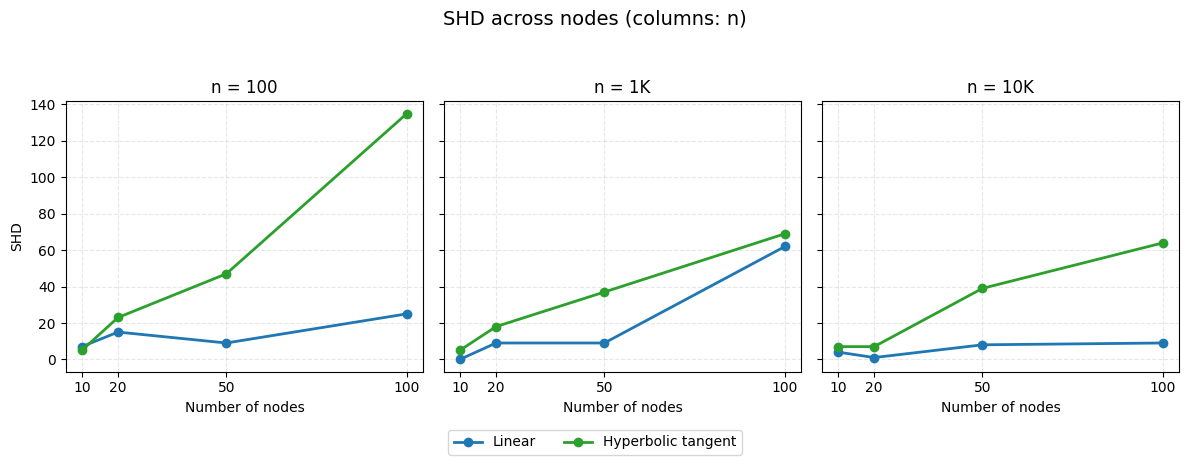

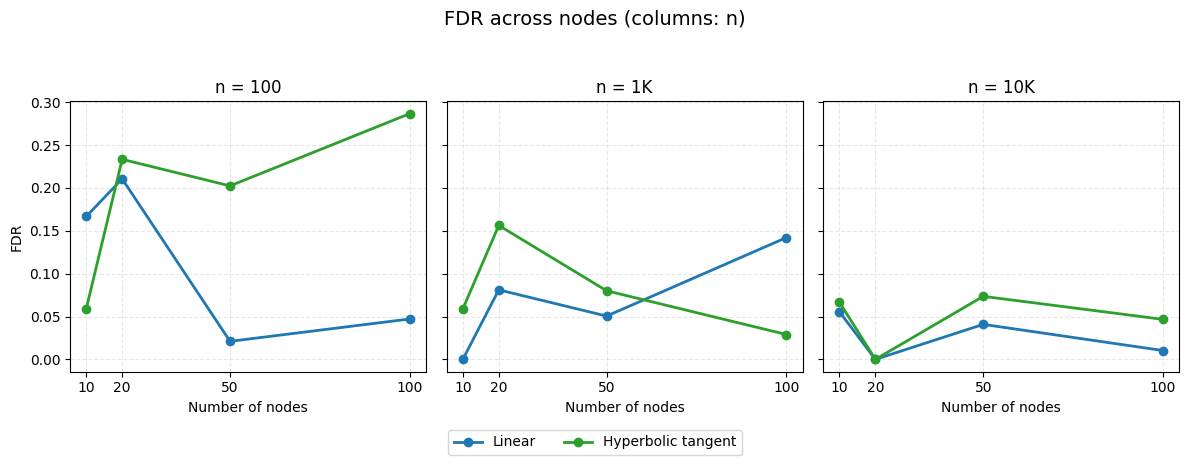

In [5]:

fig1, ax1 = plot_notears_panels(df, metric="shd",
                                samples_list=(100, 1000, 10000),
                                nodes_list=(10, 20, 50, 100),
                                figsize=(12, 4),
                                title="SHD across nodes (columns: n)",
                                savepath="fig_notears_shd.png")
fig2, ax2 = plot_notears_panels(df, metric="fdr",
                                 samples_list=(100, 1000, 10000),
                                 nodes_list=(10, 20, 50, 100),
                                 figsize=(12, 4),
                                 title="FDR across nodes (columns: n)",
                                 savepath="fig_notears_fdr.png")
plt.show()

## 1.3 Normalized SHD: 隣接行列の自由度で正規化したSHDで比較

In [1]:
import pandas as pd
import numpy as np

def F(d: int) -> int:
    """自由度 F(d) = d(d-1)/2 を返す（対角0＆(i,j)と(j,i)同一扱いの前提）。"""
    d = int(d)
    if d < 2:
        return 0
    return d * (d - 1) // 2

def add_normalized_shd(df: pd.DataFrame) -> pd.DataFrame:
    """
    入力: カラム [n_nodes, n_samples, case, shd, fdr] を持つ DataFrame
    出力: normalized_shd カラムを追加した DataFrame（元をコピーして返す）
    """
    required_cols = {"n_nodes", "n_samples", "case", "shd", "fdr"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing columns: {missing}")

    out = df.copy()
    # ベクトル化して自由度を計算
    dof = out["n_nodes"].astype(int).map(F).astype(float)
    out["normalized_shd"] = out["shd"].astype(float) / dof.replace(0, np.nan)
    # 不正値の整理（d<2等で発生する無限大は NaN に）
    out["normalized_shd"].replace([np.inf, -np.inf], np.nan, inplace=True)
    return out

# --- 使用例 ---
# df = pd.DataFrame({
#     "n_nodes":[10,20,50,100],
#     "n_samples":[100,1000,10000,100],
#     "case":["linear","tanh","linear","tanh"],
#     "shd":[8,25,120,310],
#     "fdr":[0.10,0.18,0.22,0.30],
# })
# df_norm = add_normalized_shd(df)
# print(df_norm.head())


In [5]:
df_norm = add_normalized_shd(df)

In [6]:
df_norm.head()

,n_nodes,n_samples,case,shd,fdr,normalized_shd
0,10,100,linear,7,0.166667,0.155556
1,10,100,tanh,5,0.058824,0.111111
2,10,1000,linear,0,0.000000,0.000000
3,10,1000,tanh,5,0.058824,0.111111
4,10,10000,linear,4,0.055556,0.088889


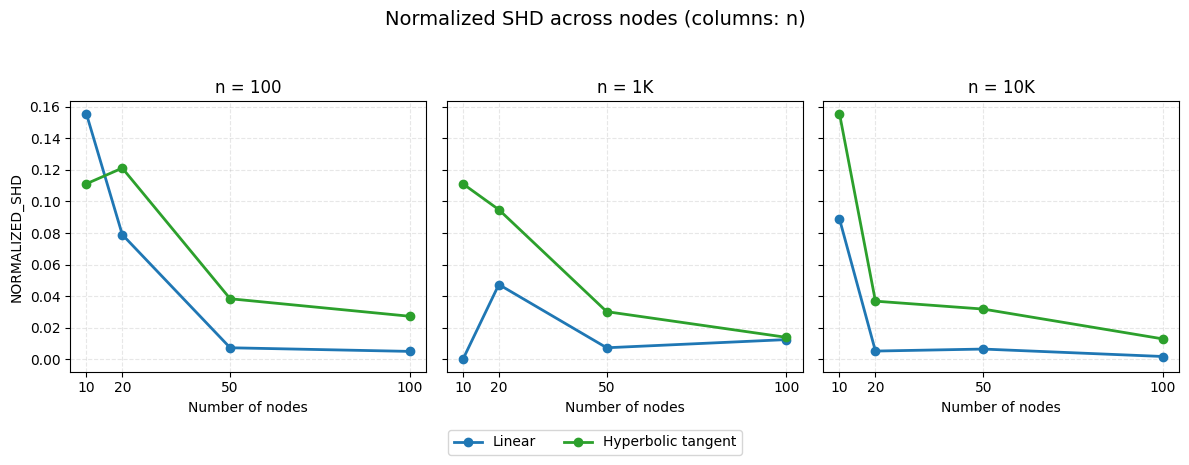

In [10]:
ig1, ax1 = plot_notears_panels(df_norm, metric="normalized_shd",
                                samples_list=(100, 1000, 10000),
                                nodes_list=(10, 20, 50, 100),
                                figsize=(12, 4),
                                title="Normalized SHD across nodes (columns: n)",
                                savepath="fig_notears_shd.png")

# 2. 非線形構造方程式モデルに対してNOTEARSの各手法（linear, mlp, sob)を適用した場合の評価

In [2]:
import os

os.chdir("/home/hashikami/projects/Diff")

In [7]:
import pandas as pd

df = pd.read_csv("results/notears_evaluate/20251016-083921/notears_eval.csv")
df_norm = add_normalized_shd(df)
df_norm.to_csv("results/notears_evaluate/20251016-083921/notears_eval_with_norm_shd.csv")

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_norm_shd_by_n(
    csv_path: str,
    savepath: str = None,
    nodes_order=(10, 20, 50, 100),
    n_values=None,   # 例: (1000, 10000)。NoneならCSVから小さい順に2つ選ぶ
    method_order=("linear", "mlp", "sob"),
    colors=None,
    figsize=(10, 4.5),
    title="Normalized SHD vs. #nodes (tanh SCM)"
):
    """
    CSV 必須カラム想定:
      - n_nodes (int)
      - n (int)               … サンプル数
      - notears_type (str)    … 'notears-linear' | 'notears-mlp' | 'notears-sob' など
      - normalized_shd (float) または norm_shd / shd_norm （自動検出）
      - seed (任意)           … あれば平均&95%CIを計算
    """

    df = pd.read_csv(csv_path)

    # 正規化SHD列名の自動検出
    shd_col_candidates = ["normalized_shd", "norm_shd", "shd_norm"]
    shd_col = next((c for c in shd_col_candidates if c in df.columns), None)
    if shd_col is None:
        raise ValueError(f"normalized SHD column not found. Tried: {shd_col_candidates}")

    # 型整理
    df["n_nodes"] = df["n_nodes"].astype(int)
    df["n"] = df["n_samples"].astype(int)
    df["notears_type"] = df["method"].astype(str)
    df[shd_col] = df[shd_col].astype(float)

    # プロット対象の n を決める（2つ）
    unique_n = sorted(df["n"].unique().tolist())
    if n_values is None:
        if len(unique_n) < 2:
            raise ValueError(f"Need at least two distinct n in CSV. Found: {unique_n}")
        n_values = unique_n[:2]
    else:
        n_values = list(n_values)
        missing = [nv for nv in n_values if nv not in unique_n]
        if missing:
            raise ValueError(f"Requested n not in CSV: {missing}. Available: {unique_n}")

    # 色
    if colors is None:
        colors = {
            "notears-linear": "tab:red",
            "notears-mlp": "tab:green",
            "notears-sob": "tab:blue",
        }

    # 事前に y 範囲を（全データから）決めておく
    yvals = df[df["notears_type"].isin(method_order)][shd_col].values
    y_min, y_max = np.nanmin(yvals), np.nanmax(yvals)
    pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
    y_lim = (y_min - pad, y_max + pad)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    for idx, n_current in enumerate(n_values):
        ax = axes[idx]
        subn = df[df["n"] == n_current]

        for method in method_order:
            subm = subn[subn["notears_type"] == method]
            if subm.empty:
                continue

            # n_nodes ごとに平均と95%CI
            g = subm.groupby("n_nodes")[shd_col]
            mean = g.mean()
            count = g.count().clip(lower=1)
            std = g.std(ddof=1)
            ci = 1.96 * (std / np.sqrt(count))  # 95% CI

            # nodes の順に並べる（欠損は落とす）
            xs, ys, cis = [], [], []
            for d in nodes_order:
                if d in mean.index:
                    xs.append(d)
                    ys.append(mean.loc[d])
                    cis.append(ci.loc[d] if d in ci.index and not np.isnan(ci.loc[d]) else 0.0)

            if len(xs) == 0:
                continue

            ax.plot(xs, ys, marker="o", linewidth=2, label=method, color=colors.get(method, None))
            # CI 帯（サンプルが1つの場合は帯幅0）
            ylow = np.array(ys) - np.array(cis)
            yhigh = np.array(ys) + np.array(cis)
            ax.fill_between(xs, ylow, yhigh, alpha=0.15, color=colors.get(method, None))

        ax.set_title(f"n = {n_current}")
        ax.set_xlabel("Number of nodes (d)")
        ax.set_xticks(list(nodes_order))
        ax.set_ylim(*y_lim)
        ax.grid(True, linestyle="--", alpha=0.3)
        if idx == 0:
            ax.set_ylabel("Normalized SHD (↓ better)")

    # 凡例は下中央に1つ
    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        for ax in axes:
            h, l = ax.get_legend_handles_labels()
            if h:
                handles, labels = h, l
                break
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=len(method_order),
                   bbox_to_anchor=(0.5, -0.05), frameon=False)

    fig.suptitle("NOTEARS variants on tanh SEM", y=1.02, fontsize=13)
    fig.tight_layout()

    if savepath:
        Path(savepath).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

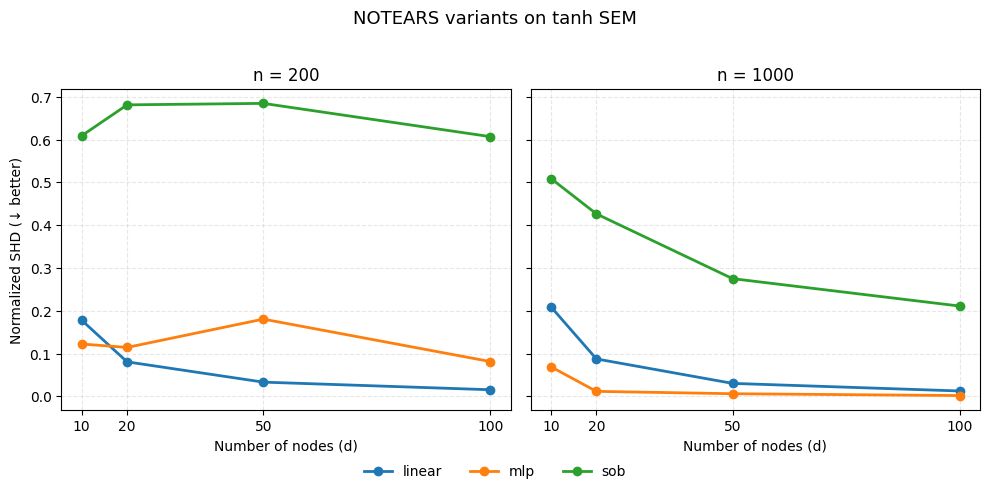

In [17]:

plot_norm_shd_by_n(
    csv_path="results/notears_evaluate/20251016-083921/notears_eval_with_norm_shd.csv",
    nodes_order=(10, 20, 50, 100),
    n_values=(200, 1000),  # CSV内のnに合わせて
    method_order=("linear", "mlp", "sob"),
)